Global imports

In [1]:
import sys
import re
import os
import cv2
import pandas as pd
import seaborn as sns
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt
import glob
import random
import time
from pathlib import Path
from tqdm import tqdm
from PIL import Image

import torch
from torch import nn

from torch.utils.data import DataLoader
from torch.utils.data import Dataset

from torchvision.utils import make_grid

# Note: this notebook requires torch >= 1.10.0
torch.__version__

'2.12.1+cpu'

Local imports

In [2]:
from src.data.plots import plot_class_distribution
from src.data.loaders import read_train_test_data_txt

In [3]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

1. Configure Base Path

In [4]:
ROOT_DIR = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT_DIR / "src"))

print(ROOT_DIR)

c:\Users\Samuel Oliveira\Desktop\CS\master-degree-project


In [5]:
TRAIN_TEST_DATA = ROOT_DIR / "data" / "UCF_Crime" / "raw"
TRAIN_TEST_DATA

WindowsPath('c:/Users/Samuel Oliveira/Desktop/CS/master-degree-project/data/UCF_Crime/raw')

In [6]:
TRAIN_TEST_SPLIT_FILES = ROOT_DIR / "data" / "UCF_Crime" / "processed" / "Anomaly_Detection_splits"
TRAIN_TEST_SPLIT_FILES

WindowsPath('c:/Users/Samuel Oliveira/Desktop/CS/master-degree-project/data/UCF_Crime/processed/Anomaly_Detection_splits')

In [7]:
train_files = read_train_test_data_txt(TRAIN_TEST_SPLIT_FILES, "Anomaly_Train")
val_files = read_train_test_data_txt(TRAIN_TEST_SPLIT_FILES, "Anomaly_Test")
# test_files = read_train_test_data_txt(TRAIN_TEST_SPLIT_FILES, "test_002")

In [8]:
from collections import Counter

class_counts = Counter(item.split("/")[0] for item in train_files)

print("\nVideos per class:")
for cls, count in sorted(class_counts.items()):
    print(f"{cls:<15} {count}")


Videos per class:
Abuse           48
Arrest          45
Arson           41
Assault         47
Burglary        87
Explosion       29
Fighting        45
Normal          430
RoadAccidents   127
Robbery         145
Shooting        27
Shoplifting     29
Stealing        95
Vandalism       45


2. Create Dataset

In [9]:
class VideoDataset(Dataset):
  def __init__(self, root_dir, data_files, num_frames=16, transform=None):
    """
    Args:
        root_dir (str): Path to the dataset directory (e.g., 'my_video_dataset/training')
        num_frames (int): Number of frames to sample from each video.
        transform (callable, optional): PyTorch transforms to apply to each frame.
    """
    self.data_files = data_files
    self.root_dir = root_dir
    self.num_frames = num_frames
    self.transform = transform
      
    # Get class names and map them to integers
    # self.classes = sorted(os.listdir(root_dir))
    self.classes = list(dict.fromkeys(file.split("/")[0] for file in self.data_files))
    
    # self.idx_to_class = {i: cls_name for cls_name, i in self.classes}
    self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
      
    # Gather all video file paths and labels
    self.video_samples = []
    
    for data in self.data_files:
      class_name = data.split("/")[0]
      file_name = data.split("/")[1]
      if file_name.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
        self.video_samples.append((os.path.join(self.root_dir, class_name, file_name), self.class_to_idx[class_name]))

  def __len__(self):
    return len(self.video_samples)

  def __getitem__(self, idx):
    video_path, label = self.video_samples[idx]
    
    # Capture frames from video
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames <= 0:
      raise ValueError(f"Error loading video or empty video file: {video_path}")
        
    # Calculate uniformly spaced frame indices
    seg_size = max(1, total_frames // self.num_frames)
    frame_indices = [min(total_frames - 1, i * seg_size) for i in range(self.num_frames)]
    
    frames = []
    for f_idx in frame_indices:
      cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
      success, frame = cap.read()
      if not success:
        # Fallback to an empty/black frame if reading fails midway
        frame = torch.zeros((3, 224, 224)) if not self.transform else None
      else:
        # Convert BGR (OpenCV default) to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = Image.fromarray(frame)
        
        if self.transform:
          frame = self.transform(frame)
              
      frames.append(frame)
        
    cap.release()
    
    # Stack frames into a single tensor
    # If your model expects shape (C, T, H, W) for 3D CNNs like ResNet3D:
    # permute channels after stacking.
    video_tensor = torch.stack(frames) # Shape: (T, C, H, W)
    video_tensor = video_tensor.permute(1, 0, 2, 3) # Shape: (C, T, H, W)
    
    return video_tensor, torch.tensor(label, dtype=torch.long)

In [10]:
# 1. Define Image/Frame transforms
# Video classification models typically require ImageNet or Kinetics normalization scales.

import torchvision.transforms as T

transform_train = T.Compose([
  T.Resize((224, 224)),
  T.ToTensor(),
  T.Normalize(mean=[0.432, 0.394, 0.376], std=[0.228, 0.221, 0.216])
])

transform_test = T.Compose([
  T.Resize((224, 224)),
  T.ToTensor(),
  T.Normalize(mean=[0.432, 0.394, 0.376], std=[0.228, 0.221, 0.216])
])


In [11]:

# 2. Instantiate Dataset
train_dataset = VideoDataset(
  root_dir=TRAIN_TEST_DATA,
  data_files=train_files, 
  num_frames=16, 
  transform=transform_train
)

val_dataset = VideoDataset(
  root_dir=TRAIN_TEST_DATA,
  data_files=val_files, 
  num_frames=16, 
  transform=transform_test
)

# test_dataset = VideoDataset(
#   root_dir=TRAIN_TEST_DATA,
#   data_files=test_files, 
#   num_frames=16, 
#   transform=video_transforms
# )

In [12]:
for i in range(10):
  video, label = train_dataset[i]
  print(label)

tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)
tensor(0)


In [13]:
for i in range(10):
  video, label = val_dataset[i]
  print(label)

tensor(0)
tensor(0)
tensor(1)
tensor(1)
tensor(1)
tensor(1)
tensor(1)
tensor(2)
tensor(2)
tensor(2)


In [14]:
print(train_dataset.class_to_idx)
print(val_dataset.class_to_idx)

print(len(train_dataset.classes))
print(len(val_dataset.classes))

print(train_dataset.classes)
print(val_dataset.classes)

{'Abuse': 0, 'Arrest': 1, 'Arson': 2, 'Assault': 3, 'Burglary': 4, 'Explosion': 5, 'Fighting': 6, 'RoadAccidents': 7, 'Robbery': 8, 'Shooting': 9, 'Shoplifting': 10, 'Stealing': 11, 'Normal': 12, 'Vandalism': 13}
{'Abuse': 0, 'Arrest': 1, 'Arson': 2, 'Assault': 3, 'Burglary': 4, 'Explosion': 5, 'Fighting': 6, 'RoadAccidents': 7, 'Robbery': 8, 'Shooting': 9, 'Shoplifting': 10, 'Stealing': 11, 'Normal': 12, 'Vandalism': 13}
14
14
['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Normal', 'Vandalism']
['Abuse', 'Arrest', 'Arson', 'Assault', 'Burglary', 'Explosion', 'Fighting', 'RoadAccidents', 'Robbery', 'Shooting', 'Shoplifting', 'Stealing', 'Normal', 'Vandalism']


In [15]:
train_dataset.transform

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.432, 0.394, 0.376], std=[0.228, 0.221, 0.216])
)

In [16]:
val_dataset.transform

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.432, 0.394, 0.376], std=[0.228, 0.221, 0.216])
)

3. Create Dataloader

In [17]:

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)
# test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

In [18]:
video, label = next(iter(train_loader))
print(video.shape)

torch.Size([16, 3, 16, 224, 224])


In [19]:
video, label = train_dataset[0]
print(video.shape, video.dtype, video.min(), video.max())

video, label = val_dataset[0]
print(video.shape, video.dtype, video.min(), video.max())

torch.Size([3, 16, 224, 224]) torch.float32 tensor(-1.8947) tensor(2.8889)
torch.Size([3, 16, 224, 224]) torch.float32 tensor(-1.8947) tensor(2.7436)


4. Define Model

In [20]:
class Conv3DBlock(nn.Module):
  def __init__(self, in_channels, out_channels, pool_kernel=(1, 2, 2)):
    super().__init__()
    self.block = nn.Sequential(
      nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
      nn.BatchNorm3d(out_channels),
      nn.ReLU(inplace=True),
      nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
      nn.BatchNorm3d(out_channels),
      nn.ReLU(inplace=True),
      nn.MaxPool3d(kernel_size=pool_kernel, stride=pool_kernel)
    )

  def forward(self, x):
    return self.block(x)

In [21]:
class Video3DCNN(nn.Module):
  def __init__(self, num_classes, in_channels=3):
    super().__init__()

    self.features = nn.Sequential(
      # Input: (B, 3, 16, 224, 224)
      Conv3DBlock(in_channels, 16, pool_kernel=(1, 2, 2)),   # -> (B,32,16,112,112)
      Conv3DBlock(16, 32,  pool_kernel=(2, 2, 2)),           # -> (B,64,8,56,56)
      Conv3DBlock(32, 64, pool_kernel=(2, 2, 2)),           # -> (B,128,4,28,28)
      Conv3DBlock(64, 128, pool_kernel=(2, 2, 2)),          # -> (B,256,2,14,14)
    )

    # AdaptiveAvgPool3d makes the classifier independent of exact T/H/W
    self.global_pool = nn.AdaptiveAvgPool3d((1, 1, 1))

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Dropout(0.5),
      nn.Linear(128, 64),
      nn.ReLU(inplace=True),
      nn.Dropout(0.3),
      nn.Linear(64, num_classes)
    )

  def forward(self, x):
    # x: (B, C, T, H, W)
    x = self.features(x)
    x = self.global_pool(x)
    x = self.classifier(x)
    
    return x

In [22]:
num_classes = len(train_dataset.classes)
num_classes

14

In [23]:
# from torchvision.models.video import r3d_18, R3D_18_Weights

# weights = R3D_18_Weights.KINETICS400_V1
# model = r3d_18(weights=weights)

# # Adapta a última camada para 14 classes do UCF-Crime
# num_classes = 14
# model.fc = nn.Linear(model.fc.in_features, num_classes)

In [24]:
# print(model)

In [25]:
num_classes = len(train_dataset.classes)
num_classes

14

In [26]:
num_classes = len(train_dataset.classes)
model = Video3DCNN(num_classes=num_classes)

video = torch.randn(1, 3, 16, 224, 224)

with torch.no_grad():
  out = model(video)
  
print(out.shape)  # torch.Size([32, num_classes])

torch.Size([1, 14])


In [27]:
print(model)

Video3DCNN(
  (features): Sequential(
    (0): Conv3DBlock(
      (block): Sequential(
        (0): Conv3d(3, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (4): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): Conv3DBlock(
      (block): Sequential(
        (0): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
        (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), paddin

---
## Train

In [28]:
from src.train import train

5. Train Model

In [29]:
# Loss and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
best_val_loss = float('inf')

In [30]:
history = train(
  model=model,
  train_dataloader=train_loader,
  test_dataloader=val_loader,
  optimizer=optimizer,
  loss_fn=loss_fn,
  epochs=10,
  device=device
)

[Epoch 0] Initial Learning Rate: 0.001000


  0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/78 [00:00<?, ?it/s]

Validation:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.2866 | train_acc: 0.3285 | test_loss: 2.2454 | test_acc: 0.5172


...

Training:   0%|          | 0/78 [00:00<?, ?it/s]

Validation:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch: 9 | train_loss: 2.0114 | train_acc: 0.3822 | test_loss: 2.1534 | test_acc: 0.2621


Training:   0%|          | 0/78 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [33]:
hist_df = pd.DataFrame(history)
hist_df.head()

,train_loss,train_acc,test_loss,test_acc
0,2.272248,0.344551,2.366692,0.158621
1,2.177940,0.356571,2.314497,0.313793
2,2.130849,0.360577,2.384168,0.265517
3,2.095700,0.366186,2.652875,0.117241
4,2.064137,0.375801,2.352895,0.341379


KeyError: 'accuracy'

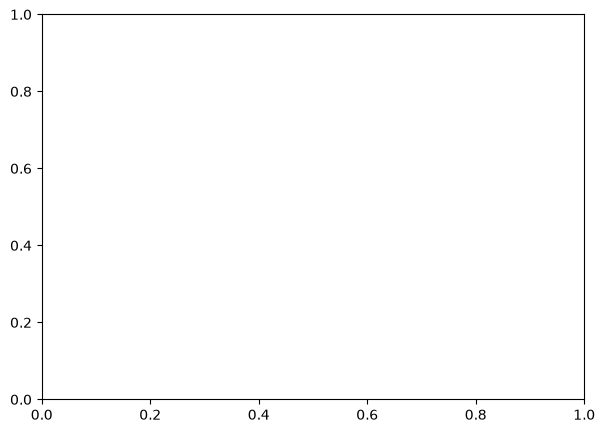

In [37]:
from src.utils.training_utils import save_history_and_plots

OUTPUT_DIR = ROOT_DIR / "outputs" / "notebooks" / "train_model"

save_history_and_plots(history, OUTPUT_DIR, "history")